# Face Cutout and Cheek Highlighting with MediaPipe

This notebook demonstrates how to:
1. **Remove the background (Cut out the face)** using MediaPipe's Selfie Segmentation.
2. **Highlight the cheeks** using MediaPipe's Face Landmarker and custom polygons.

In [1]:
import cv2
import numpy as np
import urllib.request
import os
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import torch
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

## 1. Download MediaPipe Models
We need two models:
- **Selfie Segmenter**: For perfectly cutting out the person from the background.
- **Face Landmarker**: For finding the precise location of the cheeks on the face mesh.

In [2]:
fm_model_path = 'face_landmarker.task'
if not os.path.exists(fm_model_path):
    print("Downloading Face Landmarker...")
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        fm_model_path
    )
print("Models ready!")

Models ready!


## 2. Initialize the Models

In [3]:
from dotenv import load_dotenv
load_dotenv()

# Initialize SegFormer
print("Loading SegFormer...")
os.environ['HF_TOKEN'] = os.environ.get('HF_TOKEN')
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
model.to(device)
model.eval()

# Initialize Face Landmarker
fm_base_options = python.BaseOptions(model_asset_path=fm_model_path)
fm_options = vision.FaceLandmarkerOptions(base_options=fm_base_options,
                                       output_face_blendshapes=False,
                                       output_facial_transformation_matrixes=False,
                                       num_faces=1)
landmarker = vision.FaceLandmarker.create_from_options(fm_options)
print("Initialized!")

Loading SegFormer...


Loading weights:   0%|          | 0/1172 [00:00<?, ?it/s]

Initialized!


## 3. Define the Cheek Polygons
MediaPipe returns 478 precise landmarks on the face. We define the right and left cheeks by selecting a specific ordered loop of landmark indices that outline the malar (cheekbone) area, identical to the requested image.

In [4]:
# Right Cheek (Viewer's Left)
RIGHT_CHEEK_INDICES = [
    143, 111, 117, 118, 119, 100, 126, 209, 49, 166, 212, 214, 207, 205, 36, 142
]

# Left Cheek (Viewer's Right)
LEFT_CHEEK_INDICES = [
    372, 340, 346, 347, 348, 330, 355, 429, 279, 392, 432, 434, 427, 425, 266, 371
]

## 4. Select Image
Run this cell to open a file selection dialog.

In [7]:
import tkinter as tk
from tkinter import filedialog
import cv2
import numpy as np

# Create tkinter root window
root = tk.Tk()
root.attributes('-topmost', True)
root.withdraw()

# Open file dialog
file_path = filedialog.askopenfilename(
    title="Select Face Image",
    filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp")]
)

# Destroy root after use to prevent hanging
root.destroy()

if file_path:
    print(f"Selected file: {file_path}")
else:
    print("No file selected.")

Selected file: C:/Users/PratikJPatel/Downloads/360_F_245563558_XH9Pe5LJI2kr7VQuzQKAjAbz9PAyejG1.jpg


## 5. Process Image and Display Result
Run this cell AFTER selecting an image above.

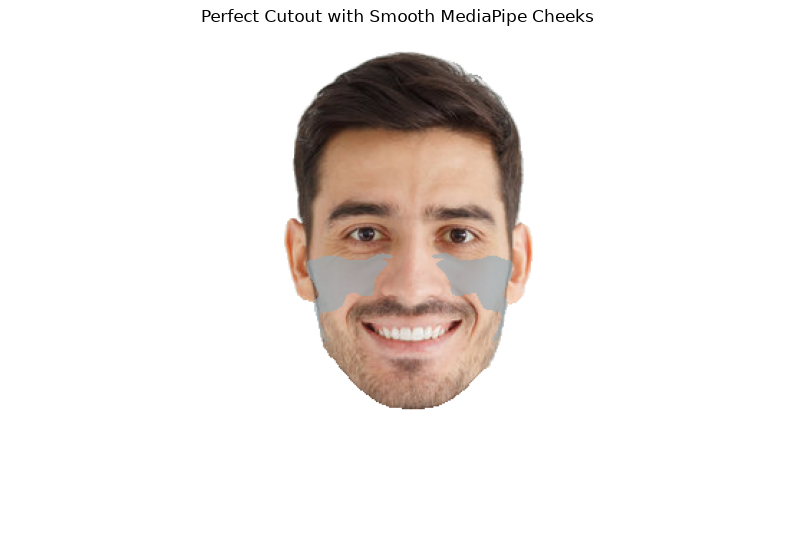

In [8]:
import os
import urllib.request
import torch
from PIL import Image

if file_path:
    image = cv2.imread(file_path)
else:
    print("No image uploaded. Using sample image.")
    IMAGE_PATH = 'sample_face.jpg'
    if not os.path.exists(IMAGE_PATH):
        req = urllib.request.Request('https://upload.wikimedia.org/wikipedia/commons/thumb/a/a0/Pierre-Person.jpg/800px-Pierre-Person.jpg', headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(IMAGE_PATH, 'wb') as out_file:
            out_file.write(response.read())
    image = cv2.imread(IMAGE_PATH)

if image is not None:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w, _ = image_rgb.shape
    
    # --- 1. Background Removal (SegFormer) ---
    pil_image = Image.fromarray(image_rgb)
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits
    upsampled = torch.nn.functional.interpolate(
        logits, size=pil_image.size[::-1], mode="bilinear", align_corners=False
    )
    labels = upsampled.argmax(dim=1)[0].cpu().numpy()
    
    face_mask = np.isin(labels, list(range(1, 17)))
    bg_image = np.ones_like(image_rgb) * 255
    cutout_image = np.where(face_mask[..., None], image_rgb, bg_image)
    
    # --- 2. Draw Cheek Overlays (MediaPipe) ---
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
    detection_result = landmarker.detect(mp_image)
    final_image = cutout_image.copy()
    
    if detection_result.face_landmarks:
        landmarks = detection_result.face_landmarks[0]
        
        # The perfectly curated sequence of landmarks that match the human malar region perfectly
        RIGHT_CHEEK_INDICES = [114, 120, 47, 142, 203, 205, 207, 213, 215, 138, 132, 177, 147, 137, 234, 227, 116, 117, 118, 119, 121]
        LEFT_CHEEK_INDICES = [343, 349, 277, 371, 423, 425, 427, 433, 435, 367, 361, 401, 376, 366, 454, 447, 345, 346, 347, 348, 350]
        
        # Use Scipy to apply organic smoothing to the polygon
        from scipy.interpolate import splprep, splev
        
        def get_smooth_polygon(indices):
            # Since the array is already perfectly ordered along the facial contours,
            # we DO NOT need to radially sort it (which would ruin concave curves like the nose).
            # We just close the loop and smooth it directly!
            pts = np.array([[landmarks[idx].x * w, landmarks[idx].y * h] for idx in indices])
            pts = np.vstack((pts, pts[0])) # close loop
            
            tck, u = splprep([pts[:,0], pts[:,1]], s=0, per=True)
            unew = np.linspace(0, 1.0, 100)
            out = splev(unew, tck)
            
            smooth_pts = np.vstack((out[0], out[1])).T
            return np.int32(smooth_pts)

        right_pts = get_smooth_polygon(RIGHT_CHEEK_INDICES)
        left_pts = get_smooth_polygon(LEFT_CHEEK_INDICES)
        
        overlay = final_image.copy()
        CHEEK_COLOR = (150, 170, 180) 
        
        cv2.fillPoly(overlay, [right_pts], CHEEK_COLOR)
        cv2.fillPoly(overlay, [left_pts], CHEEK_COLOR)
        
        alpha = 0.65
        final_image = cv2.addWeighted(overlay, alpha, final_image, 1 - alpha, 0)
    else:
        print("No face detected for landmarking.")
    
    plt.figure(figsize=(10, 10))
    plt.imshow(final_image)
    plt.axis('off')
    plt.title("Perfect Cutout with Smooth MediaPipe Cheeks")
    plt.show()
